# RAG Pipeline

Build BM25, vector, and hybrid retrieval. Run identical queries under 3 retrieval modes and include retrieved snippets as context (cite source metadata).

In [5]:
from pathlib import Path
import sys
import json, re, statistics

# Ensure project root is importable when running from notebooks/
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.ingestion.loader import load_documents
from src.ingestion.chunker import chunk_documents
from src.retrieval import BM25Retriever, VectorRetriever, fuse_scores
from src.prompt import assemble_prompt
from src.generation.ollama_client import generate_raw

# data path - change if needed
DATA_PATH = str(PROJECT_ROOT / 'data' / 'mock')
MODEL = 'gemma4:e2b'  # set to your model name

def approx_token_count(text: str) -> int:
    return len(re.findall(r'\w+|\S', text))

def normalize_text(text: str) -> str:
    return re.sub(r'\s+', ' ', text).strip()

def query_keywords(query: str) -> list[str]:
    stop = {
        'the', 'and', 'for', 'with', 'from', 'what', 'when', 'where', 'who',
        'how', 'are', 'is', 'can', 'you', 'your', 'about', 'between', 'into',
        'have', 'has', 'this', 'that', 'course', 'cs101'
    }
    tokens = re.findall(r'[a-zA-Z0-9]+', query.lower())
    return [t for t in tokens if len(t) > 2 and t not in stop]

def is_low_quality_response(text: str) -> bool:
    t = (text or '').strip()
    if not t:
        return True

    tl = t.lower()
    if t == '[Model returned an empty response]':
        return True
    if tl in {'plain text', '.', ':', 'please provide'}:
        return True
    if tl.startswith('plain text'):
        return True
    if 'output format' in tl:
        return True
    if 'bullet points with citations' in tl and len(t) < 80:
        return True
    if re.search(r'(\d)\1{6,}', t):
        return True
    if len(t) < 20:
        return True
    return False

def extractive_fallback(query: str, hits: list[tuple[str, float]], max_points: int = 3) -> str:
    if not hits:
        return 'No relevant snippets were retrieved for this query.'

    keys = set(query_keywords(query))
    candidates: list[tuple[int, int, str]] = []

    for ref_idx, (snippet, _score) in enumerate(hits[:4], start=1):
        raw = snippet.replace('\n', ' ')
        segments = [
            s.strip(' .;') for s in re.split(r'\s*;\s*|\s+-\s+|(?<=[.!?])\s+', raw)
            if s.strip()
        ]

        for seg in segments:
            seg_norm = normalize_text(seg)
            if len(seg_norm) < 12:
                continue

            words = set(re.findall(r'[a-zA-Z0-9]+', seg_norm.lower()))
            overlap = len(keys.intersection(words))
            score = overlap * 10 - ref_idx

            if seg_norm.lower().startswith('q:') and overlap == 0:
                score -= 4

            candidates.append((score, ref_idx, seg_norm))

    if not candidates:
        top = normalize_text(hits[0][0])[:180].rstrip(' ,;')
        return f'Extractive fallback summary from retrieved snippets:\n- [1] {top}'

    candidates.sort(key=lambda x: x[0], reverse=True)

    selected: list[tuple[int, str]] = []
    seen = set()
    for score, ref_idx, seg in candidates:
        key = seg.lower()
        if key in seen:
            continue
        if score < 0 and selected:
            continue

        selected.append((ref_idx, seg[:180].rstrip(' ,;')))
        seen.add(key)
        if len(selected) >= max_points:
            break

    if not selected:
        for idx, (snippet, _score) in enumerate(hits[:max_points], start=1):
            selected.append((idx, normalize_text(snippet)[:180].rstrip(' ,;')))

    lines = [f'- [{idx}] {txt}' for idx, txt in selected]
    return 'Extractive fallback summary from retrieved snippets:\n' + '\n'.join(lines)

# load and chunk documents
documents = load_documents(DATA_PATH)
chunks = chunk_documents(documents, window_tokens=200, stride_tokens=50)
chunk_texts = [c['text'] for c in chunks]

bm25 = BM25Retriever()
bm25.build(chunk_texts)
vector = VectorRetriever()
vector.build(chunk_texts)

queries = [
    'What is the assessment weighting for CS101 (coursework, midterm, final)?',
    'When are the CS101 assignment deadlines and exam dates?',
    'Who is the course convenor for CS101 and how can I contact them?',
    'Where and when are CS101 lab sessions held?',
    'How to request academic accommodation for assessments?'
]

results = { 'bm25': [], 'vector': [], 'hybrid': [] }

In [6]:
# Always start from a clean run state
results = { 'bm25': [], 'vector': [], 'hybrid': [] }
output_path = PROJECT_ROOT / 'notebooks' / 'rag_pipeline_results.json'
output_path.parent.mkdir(parents=True, exist_ok=True)
output_path.write_text('{}', encoding='utf8')

def build_prompt_with_context(query, hits):
    snippets = [f'{i+1}. {snippet[:400]}' for i, (snippet, _score) in enumerate(hits)]
    return assemble_prompt(
        role='Assistant with document context',
        task=query,
        context_snippets=snippets,
        constraints=[
            'Answer only from retrieved snippets',
            'If information is missing, clearly state what is missing',
            'Include citation tags [1], [2], [3] for supporting points',
            'Be concise and specific',
            'Do not output the words Plain text or Output Format',
        ],
        output_format='2-4 concise bullet points with citations',
    )

def run_with_quality_guard(prompt, hits, query):
    try:
        resp = generate_raw(prompt, model=MODEL, temperature=0.2, num_predict=300)
    except Exception as e:
        resp = '__error__:' + str(e)

    if is_low_quality_response(resp):
        return extractive_fallback(query, hits)

    return resp

for query in queries:
    bm25_hits = bm25.query(query, top_k=3)
    vector_hits = vector.query(query, top_k=3)
    hybrid_hits = fuse_scores(bm25_hits, vector_hits, bm25_weight=0.4, vector_weight=0.6)

    prompt_bm25 = build_prompt_with_context(query, bm25_hits)
    prompt_vector = build_prompt_with_context(query, vector_hits)
    prompt_hybrid = build_prompt_with_context(query, hybrid_hits)

    resp_bm25 = run_with_quality_guard(prompt_bm25, bm25_hits, query)
    resp_vector = run_with_quality_guard(prompt_vector, vector_hits, query)
    resp_hybrid = run_with_quality_guard(prompt_hybrid, hybrid_hits, query)

    results['bm25'].append({
        'query': query,
        'hits': bm25_hits,
        'prompt_tokens': approx_token_count(prompt_bm25),
        'response_tokens': approx_token_count(resp_bm25),
        'response': resp_bm25,
    })
    results['vector'].append({
        'query': query,
        'hits': vector_hits,
        'prompt_tokens': approx_token_count(prompt_vector),
        'response_tokens': approx_token_count(resp_vector),
        'response': resp_vector,
    })
    results['hybrid'].append({
        'query': query,
        'hits': hybrid_hits,
        'prompt_tokens': approx_token_count(prompt_hybrid),
        'response_tokens': approx_token_count(resp_hybrid),
        'response': resp_hybrid,
    })

print(f"Queries processed per mode: bm25={len(results['bm25'])}, vector={len(results['vector'])}, hybrid={len(results['hybrid'])}")
with output_path.open('w', encoding='utf8') as fh:
    json.dump(results, fh, ensure_ascii=False, indent=2)
print(f'Results saved to: {output_path}')

Queries processed per mode: bm25=5, vector=5, hybrid=5
Results saved to: c:\Users\user\Desktop\prompt-engin-proj\notebooks\rag_pipeline_results.json


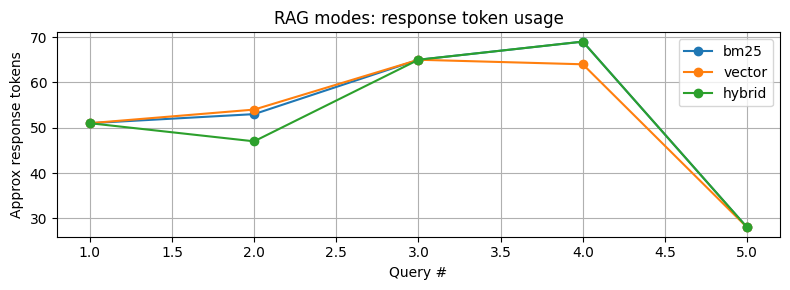

In [7]:
import matplotlib.pyplot as plt
modes = ['bm25','vector','hybrid']
avg_res_tokens = {m: [item['response_tokens'] for item in results[m]] for m in modes}
plt.figure(figsize=(8,3))
for m in modes:
    plt.plot(list(range(1,len(avg_res_tokens[m])+1)), avg_res_tokens[m], marker='o', label=m)
plt.xlabel('Query #')
plt.ylabel('Approx response tokens')
plt.title('RAG modes: response token usage')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()